In [2]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# # The coupled van der pol oscillator system
# # x1 = x[0]
# # x1dot = x[1]
# # x2 = x[2]
# # x2dot = x[3]

def coupled_vdp(t, x, lambda1=10, lambda2=5, alpha1=1.5, alpha2=1.5, beta1=0.5, beta2=0.5):
    return [x[1],
           beta1*(x[0]-x[2]) + lambda1*(1-x[0]**2) * x[1] - alpha1 * x[0],
           x[3],
           beta2*(x[2]-x[0]) + lambda2*(1-x[2]**2) * x[3] - alpha2 * x[2]]
    

In [4]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]

# If we use symmetric initial conditions in addition to symmetric system form, then x1'=x2' 
# and hence we may get a different form 
# See the discussion with Alan Kaptanoglu on Github
x0 = [1, 0, 3, 0]
sol = solve_ivp(coupled_vdp, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [5]:
# The feature names of the columns of y
feature_names = ['x1', 'x1dot', 'x2', 'x2dot']

feature_library = ps.PolynomialLibrary(degree=3)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)

initial_guess = np.zeros(())

# Optimizer
opt = ps.STLSQ(threshold=0.1)
# opt = ps.SR3(threshold=0.1, thresholder="L0")
# opt = ps.SSR(alpha=0.5)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)


# Fitting the model to the training data
model.fit(x,
          t=t)

# Print the model
model.print()

# model.get_feature_names()

(x1)' = 0.999 x1dot
(x1dot)' = -1.005 x1 + 9.941 x1dot + -0.503 x2 + -9.949 x1^2 x1dot
(x2)' = 1.000 x2dot
(x2dot)' = -0.500 x1 + -1.000 x2 + 5.000 x2dot + -4.993 x2^2 x2dot


In [6]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

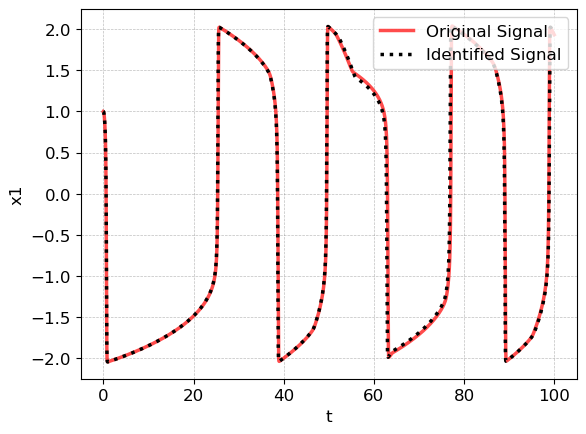

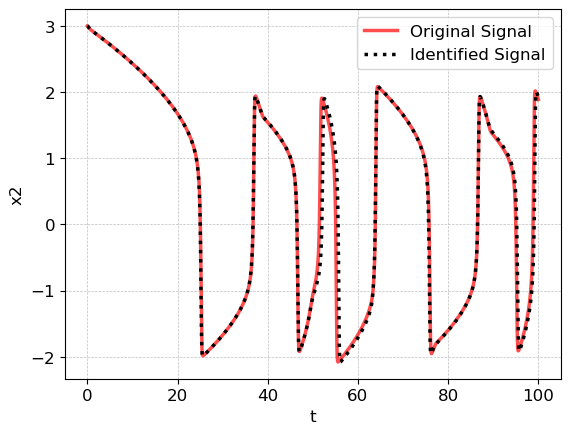

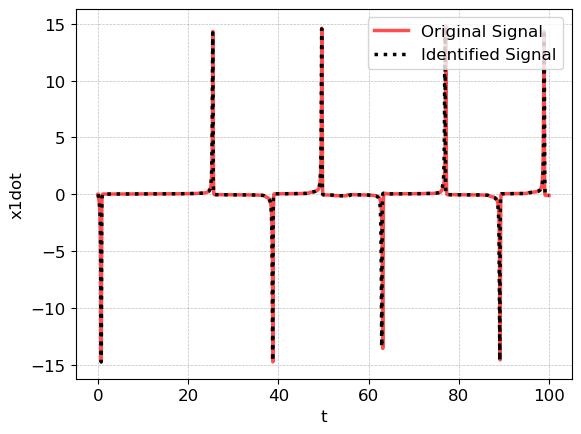

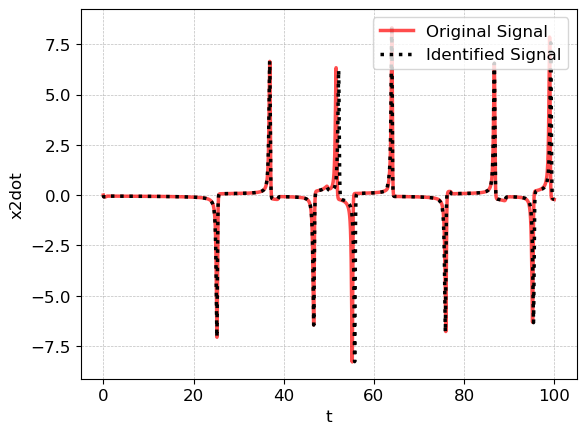

In [7]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# x1
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x1")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x1_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()

# x2
plt.plot(t,x[:,2],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,2],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x2")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x2_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()


# x1 dot
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x1dot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x1dot_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()

# x2 dot
plt.plot(t,x[:,3],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,3],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x2dot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('x2dot_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()

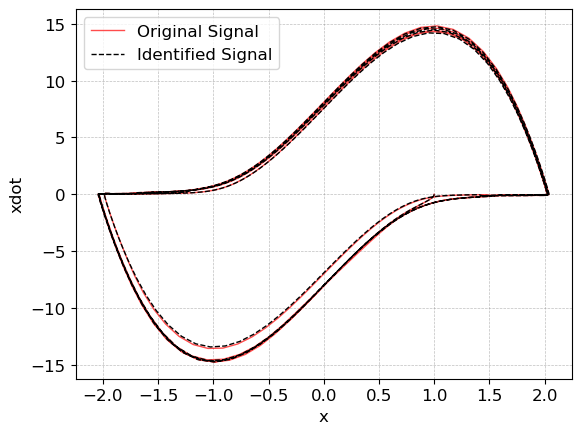

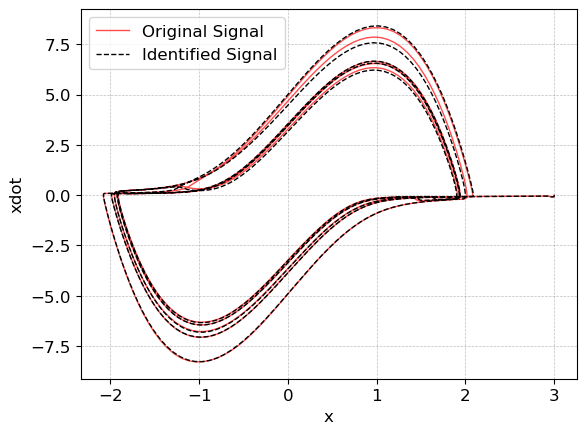

In [8]:
# Phase Portrait Oscillator 1
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=1, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=1,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_coupled_vdp_1.pdf', format='pdf', dpi=300)
plt.show()

# Phase Portrait Oscillator 2
plt.plot(x[:,2],x[:,3],'r',alpha=0.7,linewidth=1, label="Original Signal")
plt.plot(sim[:,2],sim[:,3],'k--',linewidth=1,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_coupled_vdp_2.pdf', format='pdf', dpi=300)
plt.show()

In [9]:
# Metrics

R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.9919601847329812
Mean Squared Error: 0.02191789647183352


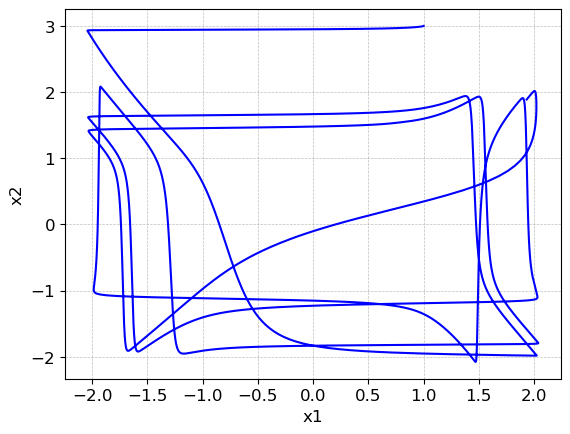

In [10]:
# Displacement Lissajous Figure
plt.plot(x[:,0],x[:,2],'b-')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('lissajous_disp_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()

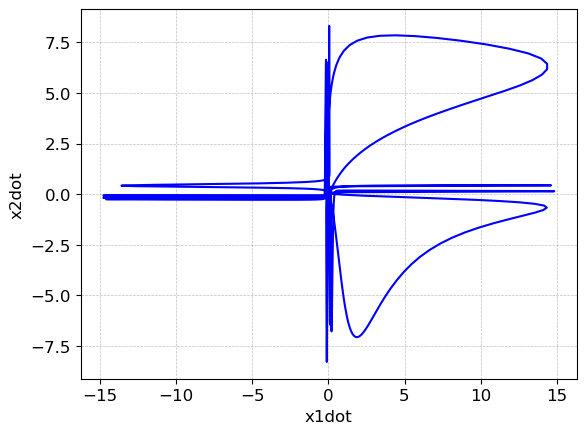

In [11]:
# Velocity Lissajous Figure
plt.plot(x[:,1],x[:,3],'b-')
plt.xlabel('x1dot')
plt.ylabel('x2dot')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('lissajous_vel_coupled_vdp.pdf', format='pdf', dpi=300)
plt.show()